# Lab 2: Signal Analysis, Sampling, Aliasing, and Filtering
Marc Pham

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7377)

## 3. Task 1: Statistical Properties of Signals

In [9]:
A = 0.5
f0 = 10
fs = 32 * f0
Tobs = 4
N = int(fs*Tobs)
n = np.arange(N)
t = n / fs

x = A * np.cos(2 * np.pi * f0 * t)

### 3.1: Mean, variance, and power

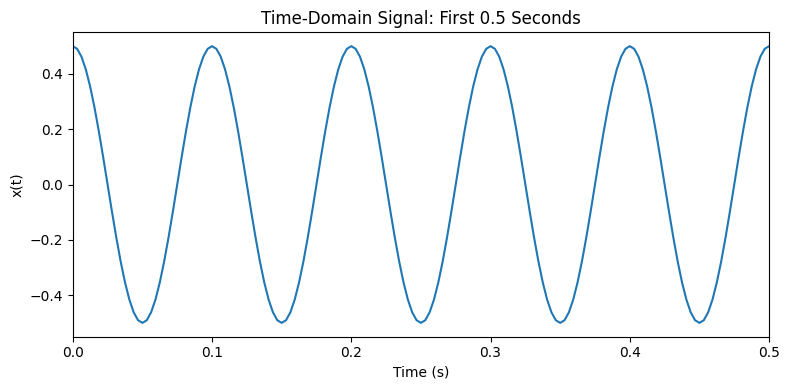

In [14]:
# Change this value to graph a different amount of time
plot_seconds = 0.5

# Select the portion of x(t) to plot
mask = t <= plot_seconds

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(t[mask], x[mask])

ax.set_xlim(0, plot_seconds)
ax.set_xlabel("Time (s)")
ax.set_ylabel("x(t)")
ax.set_title(f"Time-Domain Signal: First {plot_seconds} Seconds")

plt.tight_layout()
plt.show()


The real record $x[n] = A\cos(2\pi f_0 t)$ is a sinusoid with 5 complete cycles over the first 0.5 seconds. Each record starts and ends at equivalent points in the sinusoid, the positive and negative portions cancel exactly for the mean.

The number of samples $N=f_sT=$ 32 samples * 10 Hz * 0.5 seconds = 160 samples for the full 4 second record x[n].

Thus, over the first 0.5 seconds, the finite-record mean $\hat{\mu}_x=\frac1{N}\sum\limits_{n=0}^{N-1}A\cos(2\pi f_0 t)=0$ V.

The finite variance and finite power are $\sigma_x^2=P_x=\frac{A^2}2 = \frac{0.5^2}{2}=0.125 \text{ V}^2$.

The deterministic calculations are run below. Rounding was added to the 12th decimal places to account for Python-based round-off error.

In [21]:
# Finite-record statistics for first 0.5 seconds
x_05 = x[t < 0.5]

mean_x = np.mean(x_05)
variance_x = np.mean((x_05 - mean_x)**2)
power_x = np.mean(x_05**2)

print("N =", len(x_05))
print("Finite-record mean =", round(mean_x, 12), "V")
print("Finite-record variance =", round(variance_x, 12), "V²")
print("Finite-record power =", round(power_x, 12), "V²")


N = 160
Finite-record mean = 0.0 V
Finite-record variance = 0.125 V²
Finite-record power = 0.125 V²


The number of samples $N=f_sT=$ 32 samples * 10 Hz * 4.0 seconds = 1280 samples for the full 4 second record x[n].

The full record x[n] goes for a full 4 seconds and is a sinusoid with 40 complete cycles. Rerunning the deterministic calculation below does not change the mean, variance, and power results because both the 0.5 second and 4 second records contain an integer number of complete cycles of the 10 Hz sinusoid. Thus, both records are zero-mean sinusoids with an integer number of complete cycles.

The theoretical mean $\hat{\mu}_x=\frac1{N}\sum\limits_{n=0}^{N-1}A\cos(2\pi f_0 t)=0$ V.

The theoretical variance and theoretical power are $\sigma_x^2=P_x=\frac{A^2}2 = \frac{0.5^2}{2}=0.125 \text{ V}^2$.

In [22]:
# Theoretical statistics
mean_x2 = np.mean(x)
variance_x2 = np.mean((x - mean_x2)**2)
power_x2 = np.mean(x**2)

print("N =", len(x))
print("Finite-record mean =", round(mean_x2, 12), "V")
print("Finite-record variance =", round(variance_x2, 12), "V²")
print("Finite-record power =", round(power_x2, 12), "V²")


N = 1280
Finite-record mean = -0.0 V
Finite-record variance = 0.125 V²
Finite-record power = 0.125 V²


## 3.2: FFT

In [23]:
X = np.fft.rfft(x)
A = np.abs(X) / N

# Double all positive-frequency bins except DC and Nyquist
if N % 2 == 0: A[1:-1] *= 2 # even N, Nyquist bin exists
else: A[1:] *= 2            # odd N, no Nyquist bin

f = np.fft.rfftfreq(N, d=1/fs)

The frequency-bin spacing $\Delta f=\frac{f_s}{N}=$ 320 samples per second / 1280 samples = 0.25 Hz.

In [25]:
delta_f = fs / N
print(delta_f)

0.25


Plotting the one-sided amplitude spectrum reveals a 10 Hz component with a measured amplitude of 0.5, which is double the calculated frequency-bin spacing because the positive-frequency bins were doubled.

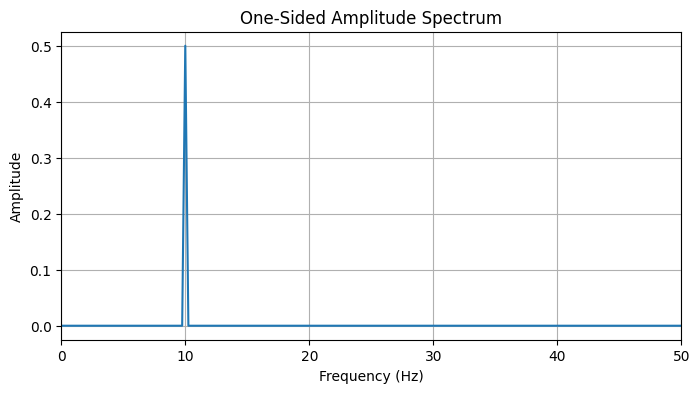

In [27]:
# Plot
plt.figure(figsize=(8, 4))
plt.plot(f, A)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('One-Sided Amplitude Spectrum')
plt.grid(True)
plt.xlim(0, 50)   # adjust as needed
plt.show()